In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.pipeline import ResearchPipeline
from src.strategies.momentum import MomentumStrategy
from src.report import PerformanceReport

In [3]:
prices = pd.read_csv(
    "../data/raw/daily_prices.csv",
    index_col=0,
    parse_dates=True
)

prices.head()

,AAPL,AMZN,GOOGL,JNJ,JPM,KO,MSFT,NVDA,TSLA,XOM
Date,,,,,,,,,,
2000-01-03,0.84,4.47,NaN,23.41,22.91,13.61,35.60,0.09,NaN,17.14
2000-01-04,0.77,4.10,NaN,22.55,22.41,13.63,34.40,0.09,NaN,16.81
2000-01-05,0.78,3.49,NaN,22.79,22.27,13.75,34.76,0.08,NaN,17.73
2000-01-06,0.71,3.28,NaN,23.50,22.59,13.77,33.60,0.08,NaN,18.65
2000-01-07,0.75,3.48,NaN,24.50,23.00,14.67,34.04,0.08,NaN,18.59


In [4]:
strategy = MomentumStrategy(
    lookback=13,
    top_n=3,
    bottom_n=3
)

pipeline = ResearchPipeline(
    strategy=strategy
)

results = pipeline.run(prices)

In [5]:
returns = results["strategy_returns"]

report = PerformanceReport()

In [6]:
summary = report.summary(
    returns
)

summary

CAGR                 0.051761
Annual Return        0.097302
Annual Volatility    0.306424
Sharpe Ratio         0.317542
Sortino Ratio        0.473330
Calmar Ratio         0.095583
Maximum Drawdown    -0.541531
Win Rate             0.518328
Best Week            0.200475
Worst Week          -0.174256
Skewness             0.162352
Kurtosis             2.343342
dtype: float64

In [7]:
charts_dir = Path("../results/charts")

charts_dir.mkdir(
    parents=True,
    exist_ok=True
)

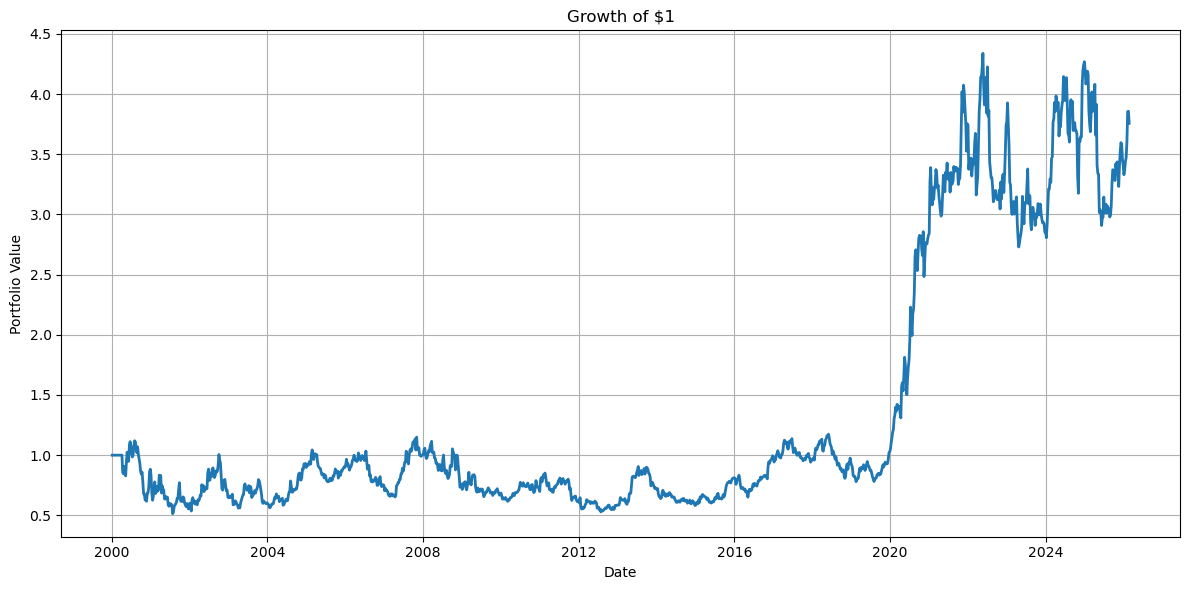

In [8]:
cumulative = report.cumulative_returns(
    returns
)

plt.figure(figsize=(12,6))

plt.plot(
    cumulative,
    linewidth=2
)

plt.title("Growth of $1")

plt.xlabel("Date")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    charts_dir / "cumulative_returns.png",
    dpi=300
)

plt.show()

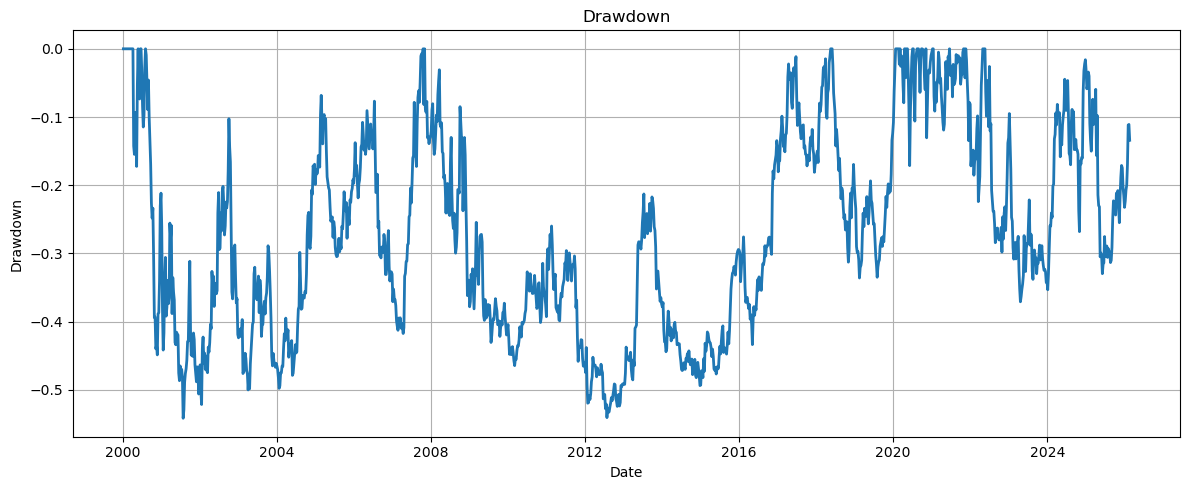

In [9]:
drawdown = report.drawdown_series(
    returns
)

plt.figure(figsize=(12,5))

plt.plot(
    drawdown,
    linewidth=2
)

plt.title("Drawdown")

plt.xlabel("Date")

plt.ylabel("Drawdown")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    charts_dir / "drawdown.png",
    dpi=300
)

plt.show()

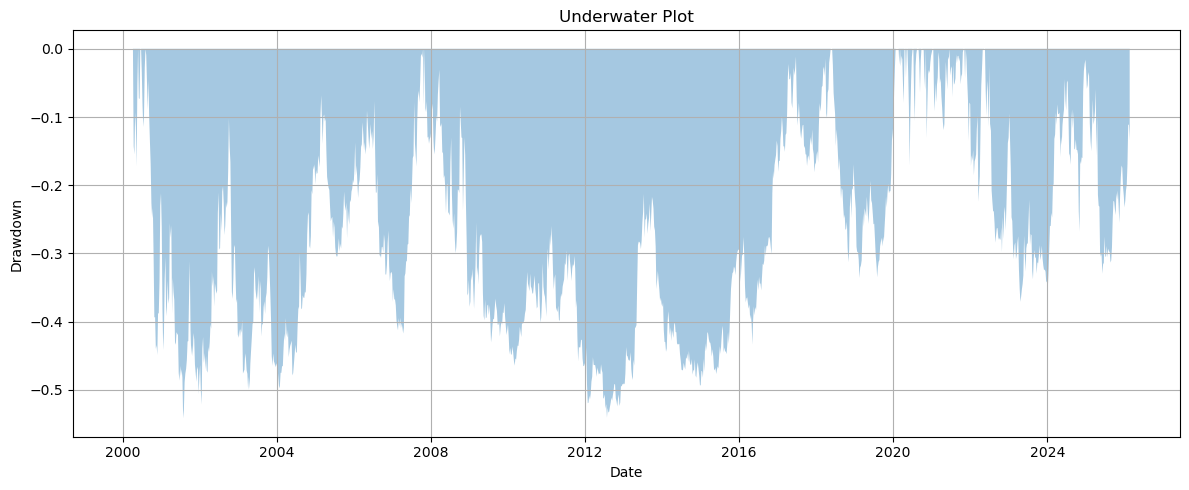

In [10]:
plt.figure(figsize=(12,5))

plt.fill_between(
    drawdown.index,
    drawdown,
    0,
    alpha=0.4
)

plt.title("Underwater Plot")

plt.xlabel("Date")

plt.ylabel("Drawdown")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    charts_dir / "underwater.png",
    dpi=300
)

plt.show()

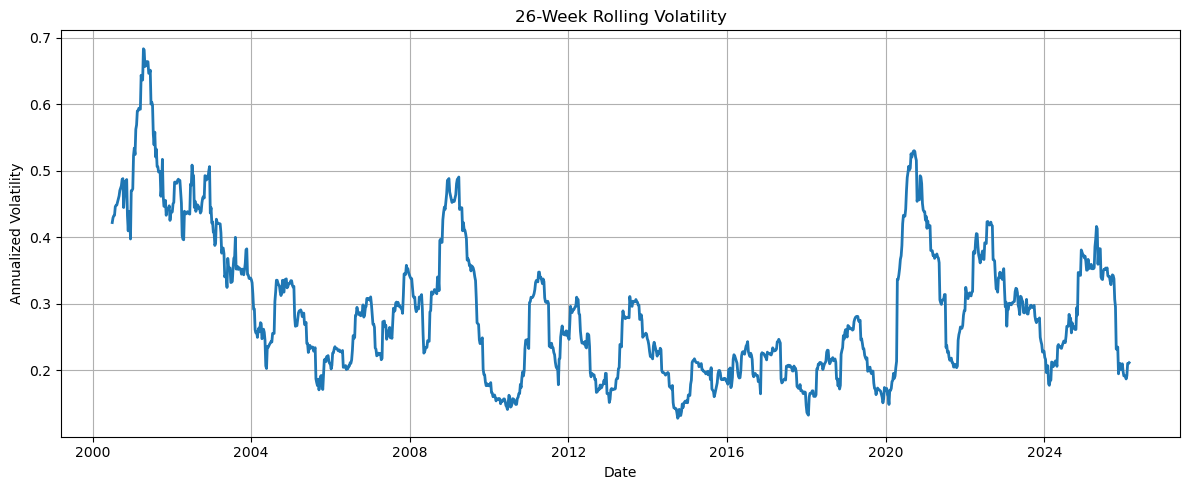

In [11]:
rolling_vol = report.rolling_volatility(
    returns
)

plt.figure(figsize=(12,5))

plt.plot(
    rolling_vol,
    linewidth=2
)

plt.title("26-Week Rolling Volatility")

plt.xlabel("Date")

plt.ylabel("Annualized Volatility")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    charts_dir / "rolling_volatility.png",
    dpi=300
)

plt.show()

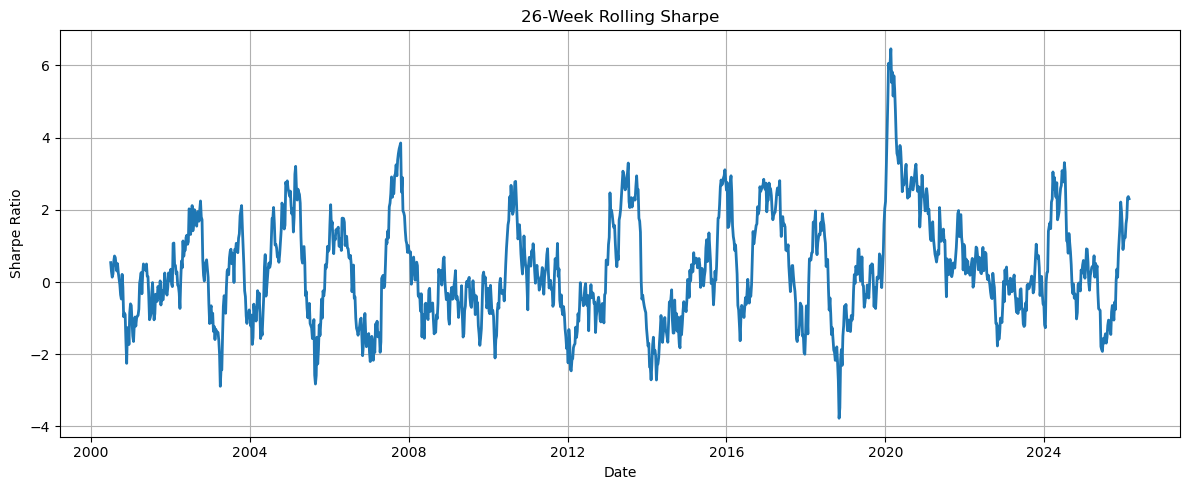

In [12]:
rolling_sharpe = report.rolling_sharpe(
    returns
)

plt.figure(figsize=(12,5))

plt.plot(
    rolling_sharpe,
    linewidth=2
)

plt.title("26-Week Rolling Sharpe")

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    charts_dir / "rolling_sharpe.png",
    dpi=300
)

plt.show()

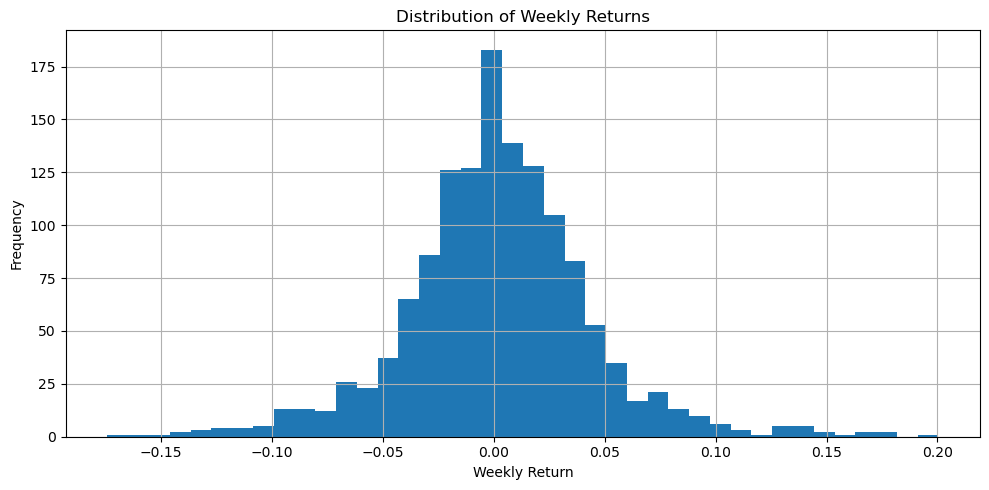

In [13]:
plt.figure(figsize=(10,5))

plt.hist(
    returns.dropna(),
    bins=40
)

plt.title("Distribution of Weekly Returns")

plt.xlabel("Weekly Return")

plt.ylabel("Frequency")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    charts_dir / "return_distribution.png",
    dpi=300
)

plt.show()

In [14]:
monthly = report.monthly_returns(
    returns
)

monthly.tail(12)

Date
2025-03-31    0.027223
2025-04-30   -0.135594
2025-05-31   -0.114083
2025-06-30    0.041171
2025-07-31   -0.042148
2025-08-31   -0.006206
2025-09-30    0.124635
2025-10-31    0.020898
2025-11-30    0.024619
2025-12-31   -0.032937
2026-01-31    0.058351
2026-02-28    0.042430
Freq: M, dtype: float64

In [15]:
yearly = report.yearly_returns(
    returns
)

yearly

Date
2000-12-31         NaN
2001-12-31   -0.339307
2002-12-31    0.115800
2003-12-31   -0.072661
2004-12-31    0.486619
2005-12-31    0.001916
2006-12-31   -0.165635
2007-12-31    0.334503
2008-12-31   -0.240825
2009-12-31   -0.110303
2010-12-31    0.032957
2011-12-31   -0.112041
2012-12-31   -0.057850
2013-12-31    0.232067
2014-12-31   -0.191228
2015-12-31    0.394000
2016-12-31    0.214672
2017-12-31   -0.028497
2018-12-31   -0.019266
2019-12-31    0.095235
2020-12-31    1.749044
2021-12-31    0.323306
2022-12-31    0.008058
2023-12-31   -0.241709
2024-12-31    0.492108
2025-12-31   -0.202293
2026-12-31    0.103256
Freq: A-DEC, dtype: float64

In [16]:
results_dir = Path("../results")

summary.to_csv(
    results_dir / "performance_report.csv"
)

monthly.to_csv(
    results_dir / "monthly_returns.csv"
)

yearly.to_csv(
    results_dir / "yearly_returns.csv"
)

print("Performance report saved successfully.")

Performance report saved successfully.


In [17]:
print("="*60)
print("QUANTLAB PERFORMANCE REPORT")
print("="*60)

print(summary)

print("\n")

print("Charts saved to:")
print(charts_dir)

QUANTLAB PERFORMANCE REPORT
CAGR                 0.051761
Annual Return        0.097302
Annual Volatility    0.306424
Sharpe Ratio         0.317542
Sortino Ratio        0.473330
Calmar Ratio         0.095583
Maximum Drawdown    -0.541531
Win Rate             0.518328
Best Week            0.200475
Worst Week          -0.174256
Skewness             0.162352
Kurtosis             2.343342
dtype: float64


Charts saved to:
..\results\charts
